In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
df = pd.read_csv('Social_Network_Ads.csv')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [17]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [18]:
df["Gender"].value_counts()

,count
Gender,
Female,204
Male,196


In [19]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [20]:
df.drop(["User ID"], axis="columns", inplace=True)

In [21]:
df["Gender"] = df["Gender"].apply(lambda x: 1 if x=="Male" else 2)

In [22]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,2,26,43000,0
3,2,27,57000,0
4,1,19,76000,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           400 non-null    int64
 1   Age              400 non-null    int64
 2   EstimatedSalary  400 non-null    int64
 3   Purchased        400 non-null    int64
dtypes: int64(4)
memory usage: 12.6 KB


In [24]:
df.describe()

,Gender,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000,400.000000
mean,1.510000,37.655000,69742.500000,0.357500
std,0.500526,10.482877,34096.960282,0.479864
min,1.000000,18.000000,15000.000000,0.000000
25%,1.000000,29.750000,43000.000000,0.000000
50%,2.000000,37.000000,70000.000000,0.000000
75%,2.000000,46.000000,88000.000000,1.000000
max,2.000000,60.000000,150000.000000,1.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x787b5d632390>,
 'caps': [<matplotlib.lines.Line2D at 0x787b5d632ae0>,
 'boxes': [<matplotlib.lines.Line2D at 0x787b5d60dac0>],
 'medians': [<matplotlib.lines.Line2D at 0x787b5d6330b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x787b5d633290>],
 'means': []}

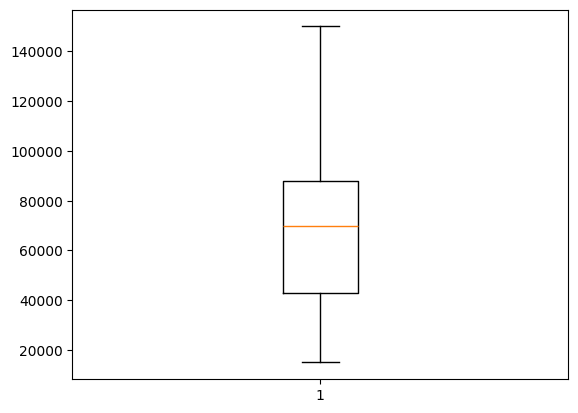

In [25]:
plt.boxplot(df['EstimatedSalary'])

In [26]:
x = df.drop(['Purchased'], axis='columns')
y = df.Purchased

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=35)

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [31]:
x_train[:5]

array([[ 0.96922337,  0.79382878, -0.84043596],
       [ 0.96922337, -1.44556555,  0.36346401],
       [ 0.96922337,  0.01490901,  1.24436643],
       [-1.03175391, -1.34820058, -0.42934817],
       [-1.03175391,  0.20963895, -0.25316768]])

In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
model = KNeighborsClassifier()
model.fit(x_train, y_train)

KNeighborsClassifier()

In [34]:
model.score(x_test, y_test)

0.9375

In [35]:
y_pred = model.predict(x_test)

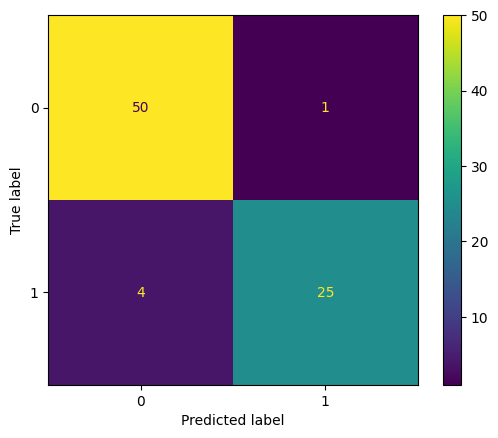

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, x_test, y_test)